# Bouncer — End-to-End Demo

**Bouncer** is a context-aware QC and feature-registration tool for bioinformatics assay data.

This notebook walks through the full workflow:

| Step | What happens |
|------|-------------|
| 1 | Run QC on a **correct** qPCR dataset → `PASS` |
| 2 | Inspect the QC report and individual findings |
| 3 | Register the validated data to the feature store (AnnData + DuckDB) |
| 4 | Explore the resulting AnnData object |
| 5 | Run QC on an **incorrect** dataset → `FAIL`, read the fix guide |
| 6 | Pull data from the store with `bouncer.pull_data()` |
| 7 | Visualise: CT heatmap, replicate SD, condition comparison |

In [1]:
import os
os.chdir('/Users/kghatole/Documents/my_projects/Bio-data-aws')

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import bouncer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
print(f'bouncer v{bouncer.__version__}')

bouncer v0.1.0


---
## 1 — Define paths

In [2]:
SCHEMA       = 'schema/basic-schema.yaml'
QC_CONTRACT  = 'schema/basic-qc.yaml'

CORRECT_CT   = 'qPCR/correct/Ct.csv'
CORRECT_SS   = 'qPCR/correct/samplesheet-qpcr - correct.csv'
CORRECT_PDF  = 'qPCR/correct/protocol.pdf'

WRONG_CT     = 'qPCR/incorrect/Ct.csv'
WRONG_SS     = 'qPCR/incorrect/samplesheet-qpcr - incorrect.csv'

---
## 2 — QC on a correct dataset

`bouncer.check()` parses all inputs, runs every check in `basic-qc.yaml`, and prints a report.

In [3]:
result = bouncer.check(
    ct_export   = CORRECT_CT,
    samplesheet = CORRECT_SS,
    schema      = SCHEMA,
    qc_contract = QC_CONTRACT,
    protocol    = CORRECT_PDF,
    verbose     = True,
)

BOUNCER QC REPORT
Assay type : QPCR
Schema     : v1.0.0
Experiment : EXP_2024_001
Plate      : PLT_001  Run date: 2024-03-01
Operator   : Jane Smith

Overall status : PASS ✓
  Hard failures : 0  (block registration)
  Soft failures : 0  (logged as warnings)
  Advisories    : 2  (design / metadata)

[CT Export Integrity]  — all checks passed
[NTC Contamination]
  ℹ WARN  ntc_present_per_target
         No NTC well found for 4 target(s): ACTB, BCL2, GAPDH, MYC.

[Reference Genes]  — all checks passed
[Samplesheet Integrity]  — all checks passed
[Cross-File Concordance]  — all checks passed
[Experimental Design]
  ℹ WARN  min_biological_replicates_per_condition
         Condition(s) with < 3 (recommended) biological replicates: control(2), treated(2).

Registration is allowed. Run bouncer.register() to push to feature store.


---
## 3 — Inspect findings programmatically

The `QCResult` object exposes findings as structured Python objects — useful for automated CI gates.

In [4]:
print(f'Passed : {result.passed}')
print(f'Hard   : {len(result.hard_failures)}')
print(f'Soft   : {len(result.soft_failures)}')
print(f'Warn   : {len(result.warnings)}')

Passed : True
Hard   : 0
Soft   : 0
Warn   : 2


In [5]:
# All findings as a DataFrame — handy for logging or CI artefacts
rows = [
    dict(
        severity = f.severity.value,
        section  = f.section,
        check    = f.check,
        message  = f.message,
    )
    for f in result.findings
]
findings_df = pd.DataFrame(rows)
findings_df

,severity,section,check,message
0,warning,ntc,ntc_present_per_target,"No NTC well found for 4 target(s): ACTB, BCL2,..."
1,warning,design,min_biological_replicates_per_condition,Condition(s) with < 3 (recommended) biological...


---
## 4 — Register to the feature store

`bouncer.register()` converts the validated data to **AnnData** and writes it to a local DuckDB database.
It raises `RuntimeError` if any hard failures are present.

In [6]:
import os
# Reset demo store each run
if os.path.exists('bouncer_store.duckdb'):
    os.remove('bouncer_store.duckdb')

adata = bouncer.register(result)
adata

Registered experiment 'EXP_2024_001' — 4 samples × 4 targets.


AnnData object with n_obs × n_vars = 4 × 4
    obs: 'organism', 'tissue', 'cell_type', 'condition', 'biological_replicate', 'batch', 'sex', 'passage_number', 'experiment_id', 'plate_id', 'cdna_input_ng', 'cdna_concentration_ng_uL', 'reverse_transcription_kit', 'master_mix', 'protocol_version'
    var: 'target_type', 'primer_assay_id'
    uns: 'assay_type', 'schema_version', 'registration_timestamp', 'plate_barcode', 'run_date', 'operator', 'experiment_name', 'qc_warnings'
    layers: 'ct_sd'

---
## 5 — Explore the AnnData object

- **`.X`** — mean Ct per sample × target
- **`.layers['ct_sd']`** — technical replicate SD
- **`.obs`** — sample metadata (condition, organism, sex, batch …)
- **`.var`** — target metadata (target_type, primer_assay_id)
- **`.uns`** — plate provenance + QC warnings

In [7]:
print('=== .X  (mean Ct) ===')
ct_df = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
print(ct_df.round(2))

=== .X  (mean Ct) ===
           ACTB       BCL2      GAPDH        MYC
S001  20.070000  30.879999  19.280001  27.510000
S002  20.230000  30.780001  19.469999  27.549999
S003  20.120001  28.090000  19.219999  25.090000
S004  20.280001  28.200001  19.580000  25.180000


In [8]:
print('=== .layers[ct_sd]  (technical replicate SD) ===')
sd_df = pd.DataFrame(adata.layers['ct_sd'], index=adata.obs_names, columns=adata.var_names)
print(sd_df.round(3))

=== .layers[ct_sd]  (technical replicate SD) ===
       ACTB   BCL2  GAPDH    MYC
S001  0.036  0.066  0.044  0.066
S002  0.056  0.062  0.072  0.060
S003  0.036  0.046  0.046  0.044
S004  0.046  0.050  0.070  0.040


In [9]:
print('=== .obs  (sample metadata) ===')
adata.obs[['condition', 'organism', 'tissue', 'sex', 'biological_replicate', 'batch']]

=== .obs  (sample metadata) ===


,condition,organism,tissue,sex,biological_replicate,batch
S001,control,Homo sapiens,PBMC,female,1,2024-03-01_batch1
S002,control,Homo sapiens,PBMC,male,2,2024-03-01_batch1
S003,treated,Homo sapiens,PBMC,female,1,2024-03-01_batch1
S004,treated,Homo sapiens,PBMC,male,2,2024-03-01_batch1


In [10]:
print('=== .var  (target metadata) ===')
adata.var

=== .var  (target metadata) ===


,target_type,primer_assay_id
ACTB,reference,Hs01060665_g1
BCL2,target,Hs00608023_m1
GAPDH,reference,Hs02786624_g1
MYC,target,Hs00153408_m1


In [11]:
print('=== .uns  (plate provenance) ===')
for k, v in adata.uns.items():
    if k != 'qc_warnings':
        print(f'  {k}: {v}')
print('  qc_warnings:')
for w in adata.uns['qc_warnings']:
    print(f"    [{w['severity'].upper()}] {w['check']}: {w['message']}")

=== .uns  (plate provenance) ===
  assay_type: qpcr
  schema_version: 1.0.0
  registration_timestamp: 2026-04-28T02:25:03.560539
  plate_barcode: PLT_001
  run_date: 2024-03-01
  operator: Jane Smith
  experiment_name: EXP_2024_001
  qc_warnings:
    [WARNING] ntc_present_per_target: No NTC well found for 4 target(s): ACTB, BCL2, GAPDH, MYC.
    [WARNING] min_biological_replicates_per_condition: Condition(s) with < 3 (recommended) biological replicates: control(2), treated(2).


---
## 6 — QC on an incorrect dataset

The incorrect samplesheet marks **ACTB** as both `reference` and `target` — a hard failure.
Bouncer blocks registration and prints a fix guide.

In [12]:
bad_result = bouncer.check(
    ct_export   = WRONG_CT,
    samplesheet = WRONG_SS,
    schema      = SCHEMA,
    qc_contract = QC_CONTRACT,
    verbose     = True,
)

BOUNCER QC REPORT
Assay type : QPCR
Schema     : v1.0.0
Experiment : EXP_2024_001
Plate      : PLT_001  Run date: 2024-03-01
Operator   : Jane Smith

Overall status : FAIL ✗
  Hard failures : 1  (block registration)
  Soft failures : 0  (logged as warnings)
  Advisories    : 2  (design / metadata)

[CT Export Integrity]  — all checks passed
[NTC Contamination]
  ℹ WARN  ntc_present_per_target
         No NTC well found for 4 target(s): ACTB, BCL2, GAPDH, MYC.

[Reference Genes]
  ✖ HARD  reference_gene_not_in_targets
         Gene(s) listed as both reference and target: ACTB.

[Samplesheet Integrity]  — all checks passed
[Cross-File Concordance]  — all checks passed
[Experimental Design]
  ℹ WARN  min_biological_replicates_per_condition
         Condition(s) with < 3 (recommended) biological replicates: control(2), treated(2).

Registration BLOCKED. Fix hard failures above before re-submitting.

Fix guide:
  1. [reference_genes] reference_gene_not_in_targets: Gene(s) listed as both ref

In [13]:
# Attempting to register raises immediately
try:
    bouncer.register(bad_result)
except RuntimeError as e:
    print('Caught RuntimeError:')
    print(e)

Caught RuntimeError:
Registration blocked — 1 hard failure(s):
  - reference_gene_not_in_targets: Gene(s) listed as both reference and target: ACTB.
Fix the issues above and re-run bouncer.check().


---
## 7 — Pull data from the feature store

`bouncer.pull_data()` returns a long-form DataFrame filtered by any metadata dimension.
Pass `as_anndata=True` to get back an AnnData directly.

In [14]:
# All qPCR data
df_all = bouncer.pull_data(assay=['qpcr'])
print(f'{len(df_all)} rows  |  columns: {list(df_all.columns)}')
df_all[['sample_id','target_name','ct_mean','ct_sd','condition','organism','sex']].head(8)

16 rows  |  columns: ['experiment_id', 'sample_id', 'target_name', 'target_type', 'ct_mean', 'ct_sd', 'assay_type', 'organism', 'tissue', 'cell_type', 'condition', 'biological_replicate', 'batch', 'sex', 'passage_number', 'plate_id', 'cdna_input_ng', 'cdna_concentration_ng_uL', 'reverse_transcription_kit', 'master_mix', 'primer_assay_id', 'protocol_version']


,sample_id,target_name,ct_mean,ct_sd,condition,organism,sex
0,S001,ACTB,20.070000,0.036056,control,Homo sapiens,female
1,S001,BCL2,30.879999,0.065574,control,Homo sapiens,female
2,S001,GAPDH,19.280001,0.043589,control,Homo sapiens,female
3,S001,MYC,27.510000,0.065574,control,Homo sapiens,female
4,S002,ACTB,20.230000,0.055678,control,Homo sapiens,male
5,S002,BCL2,30.780001,0.062450,control,Homo sapiens,male
6,S002,GAPDH,19.469999,0.072111,control,Homo sapiens,male
7,S002,MYC,27.549999,0.060000,control,Homo sapiens,male


In [15]:
# Treated samples only
df_treated = bouncer.pull_data(assay=['qpcr'], condition=['treated'])
print(f'Treated rows: {len(df_treated)}')
df_treated[['sample_id','target_name','ct_mean','condition']]

Treated rows: 8


,sample_id,target_name,ct_mean,condition
0,S003,ACTB,20.120001,treated
1,S003,BCL2,28.090000,treated
2,S003,GAPDH,19.219999,treated
3,S003,MYC,25.090000,treated
4,S004,ACTB,20.280001,treated
5,S004,BCL2,28.200001,treated
6,S004,GAPDH,19.580000,treated
7,S004,MYC,25.180000,treated


In [16]:
# Target genes only (exclude reference)
df_targets = bouncer.pull_data(assay=['qpcr'], target_type=['target'])
print(f'Target-gene rows: {len(df_targets)}')
df_targets[['sample_id','target_name','ct_mean','condition']]

Target-gene rows: 8


,sample_id,target_name,ct_mean,condition
0,S001,BCL2,30.879999,control
1,S001,MYC,27.510000,control
2,S002,BCL2,30.780001,control
3,S002,MYC,27.549999,control
4,S003,BCL2,28.090000,treated
5,S003,MYC,25.090000,treated
6,S004,BCL2,28.200001,treated
7,S004,MYC,25.180000,treated


In [17]:
# As AnnData
adata_pulled = bouncer.pull_data(assay=['qpcr'], as_anndata=True)
adata_pulled

AnnData object with n_obs × n_vars = 4 × 4
    obs: 'experiment_id', 'assay_type', 'organism', 'tissue', 'cell_type', 'condition', 'biological_replicate', 'batch', 'sex', 'passage_number', 'plate_id', 'cdna_input_ng', 'cdna_concentration_ng_uL', 'reverse_transcription_kit', 'master_mix', 'protocol_version'
    var: 'target_type', 'primer_assay_id'
    layers: 'ct_sd'

In [18]:
# List registered experiments
bouncer.list_experiments()

,experiment_id,assay_type,schema_version,plate_barcode,run_date,operator,registered_at
0,EXP_2024_001,qpcr,1.0.0,PLT_001,2024-03-01,Jane Smith,2026-04-27 19:25:10.032125


---
## 8 — Visualisations

### 8a — CT heatmap (mean Ct per sample × target)

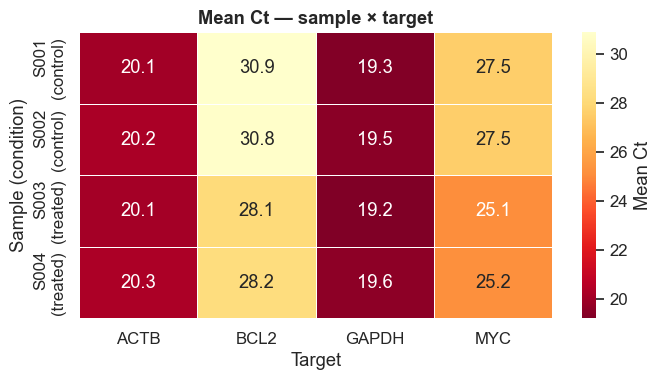

In [19]:
ct_matrix = pd.DataFrame(
    adata.X,
    index=adata.obs['condition'].values.tolist(),
    columns=adata.var_names,
)
# Rename index to show sample + condition
ct_matrix.index = [f'{sid}\n({cond})' for sid, cond in
                   zip(adata.obs_names, adata.obs['condition'])]

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    ct_matrix,
    annot=True, fmt='.1f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    cbar_kws={'label': 'Mean Ct'},
    ax=ax,
)
ax.set_title('Mean Ct — sample × target', fontweight='bold')
ax.set_xlabel('Target')
ax.set_ylabel('Sample (condition)')
plt.tight_layout()
plt.show()

### 8b — Technical replicate SD heatmap

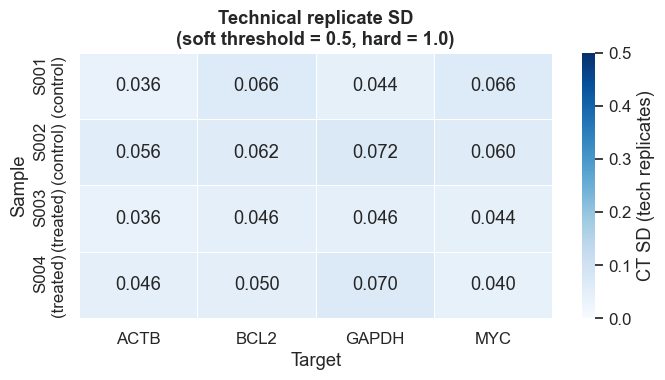

In [20]:
sd_matrix = pd.DataFrame(
    adata.layers['ct_sd'],
    index=[f'{sid}\n({cond})' for sid, cond in
           zip(adata.obs_names, adata.obs['condition'])],
    columns=adata.var_names,
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    sd_matrix,
    annot=True, fmt='.3f',
    cmap='Blues',
    linewidths=0.5,
    vmin=0, vmax=0.5,
    cbar_kws={'label': 'CT SD (tech replicates)'},
    ax=ax,
)
ax.set_title('Technical replicate SD\n(soft threshold = 0.5, hard = 1.0)', fontweight='bold')
ax.set_xlabel('Target')
ax.set_ylabel('Sample')
plt.tight_layout()
plt.show()

### 8c — Ct by condition (box + strip)

Target genes only — what you would hand to a delta-Ct normalisation step.

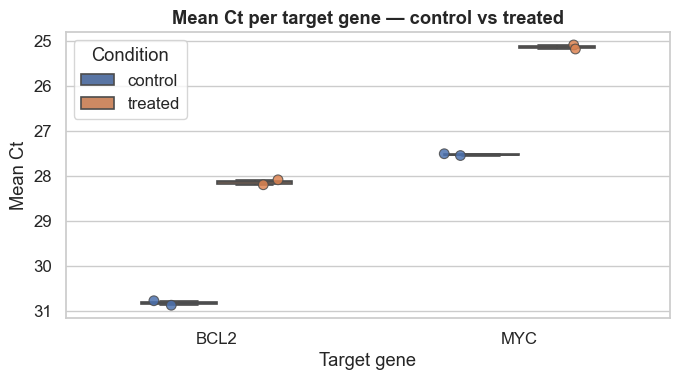

In [21]:
df_tgt = df_all[df_all['target_type'] == 'target'].copy()

fig, ax = plt.subplots(figsize=(7, 4))
palette = {'control': '#4C72B0', 'treated': '#DD8452'}

sns.boxplot(
    data=df_tgt, x='target_name', y='ct_mean',
    hue='condition', palette=palette,
    width=0.5, linewidth=1.2, fliersize=0, ax=ax,
)
sns.stripplot(
    data=df_tgt, x='target_name', y='ct_mean',
    hue='condition', palette=palette,
    dodge=True, size=7, linewidth=0.8, alpha=0.85, ax=ax,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Condition', frameon=True)
ax.set_title('Mean Ct per target gene — control vs treated', fontweight='bold')
ax.set_xlabel('Target gene')
ax.set_ylabel('Mean Ct')
ax.invert_yaxis()   # lower Ct = higher expression
plt.tight_layout()
plt.show()

### 8d — Reference gene stability (CV across samples)

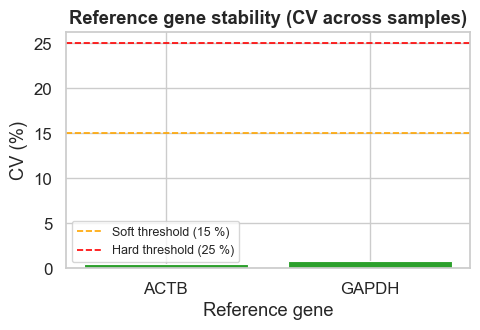

target_name      mean      std       cv
       ACTB 20.174999 0.096782 0.004797
      GAPDH 19.387501 0.166808 0.008604


In [22]:
df_ref = df_all[df_all['target_type'] == 'reference'].copy()

cv_data = (
    df_ref.groupby('target_name')['ct_mean']
    .agg(mean='mean', std='std')
    .assign(cv=lambda d: d['std'] / d['mean'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(cv_data['target_name'], cv_data['cv'] * 100,
              color=['#2ca02c' if v < 15 else '#d62728' for v in cv_data['cv'] * 100],
              edgecolor='white', linewidth=0.8)

ax.axhline(15, color='orange', linestyle='--', linewidth=1.2, label='Soft threshold (15 %)')
ax.axhline(25, color='red',    linestyle='--', linewidth=1.2, label='Hard threshold (25 %)')
ax.set_ylabel('CV (%)')
ax.set_xlabel('Reference gene')
ax.set_title('Reference gene stability (CV across samples)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(cv_data.to_string(index=False))

---
## Summary

| API call | What it does |
|---|---|
| `bouncer.check(ct_export, samplesheet, schema, qc_contract)` | Run all QC checks, print report, return `QCResult` |
| `result.passed` / `.hard_failures` / `.findings` | Programmatic access to QC outcomes |
| `bouncer.register(result)` | Convert validated data → AnnData, push to DuckDB store |
| `bouncer.pull_data(assay=['qpcr'])` | Query store by any metadata dimension |
| `bouncer.pull_data(..., as_anndata=True)` | Return result as AnnData instead of DataFrame |
| `bouncer.list_experiments()` | Inventory of registered experiments |